# Weight Function Example

This notebook demonstrates how to compute scintillation weight functions using `pyweif`.

The weight function $W(z)$ describes the contribution of a thin atmospheric turbulence layer at altitude $z$ to the observed scintillation variance. It integrates the Kolmogorov turbulence spectrum over spatial frequencies, taking into account the optical system's aperture geometry and spectral response:

$$
W(z) = 9.69 \cdot 10^{-3} \cdot 32 \pi^3 z^{5/6} \lambda^{-7/6} \int_0^{\infty} du\, u^{-8/3} S(u) A\left(\frac{D}{\sqrt{\lambda z}} u\right),
$$

where $S(u)$ is a spectral filter, $\lambda$ is its equivalent wavelength, and $A(u)$ is an aperture filter.

**[Run this NB in Google Colab](https://colab.research.google.com/github/matwey/pyweif/blob/master/docs/notebooks/weight_function.ipynb)**

## Install and import the required libraries

In [1]:
%pip install pyweif synphot

Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from synphot import SpectralElement
from astropy import units as u
from pyweif import SpectralResponse, WeightFunction, WeightFunction2d
import pyweif.sf as sf
import pyweif.af as af

## Create aperture filters

We construct two different aperture filters since we are going to compare impact of the aperture shape on the result.

In [3]:
APERTURE_SCALE = 20.574

af_circular = af.Circular()
af_point = af.Point()

## Load Johnson V response curve from `synphot`

In [4]:
bp_v = SpectralElement.from_filter('johnson_v')

grid = bp_v.waveset.to(u.nm)
data = bp_v(grid)
origin = grid[0].value
delta = (grid[1] - grid[0]).value

eff_lambda = bp_v.avgwave()

spectral_response = SpectralResponse(data, origin=origin, delta=delta)

### Create polychromatic spectral filter

In [5]:
spectral_response.normalize()

sf_poly = sf.Poly(spectral_response, 4096)
equiv_lambda = sf_poly.equiv_lambda()
sf_poly.normalize()

### Create monochromatic spectral filter

We are going to use it in conjunction with `equiv_lambda` wavelength.

In [6]:
sf_mono = sf.Mono()

### Create Gaussian spectral filter

We are going to use it in conjunction with `eff_lambda` wavelength.

In [7]:
sf_gauss = sf.Gauss(fwhm = (bp_v.fwhm() / eff_lambda).value)

## Evaluate and plot the weight functions

### Compare scintillation with the point aperture

The results are the same for different spectral filters, this is expected.

In [8]:
Z = np.linspace(0, 32, 1000)

In [9]:
wf_point_mono = WeightFunction(sf_mono, equiv_lambda, af_point, APERTURE_SCALE, 1024)
wf_point_poly = WeightFunction(sf_poly, equiv_lambda, af_point, APERTURE_SCALE, 1024)

For considered simple case we also have exact equation

In [10]:
wf_exact_mono = 9.69e-3 * 32*np.pi**3 * 1e13 * Z**(5/6) / equiv_lambda**(7/6) * 1.9991

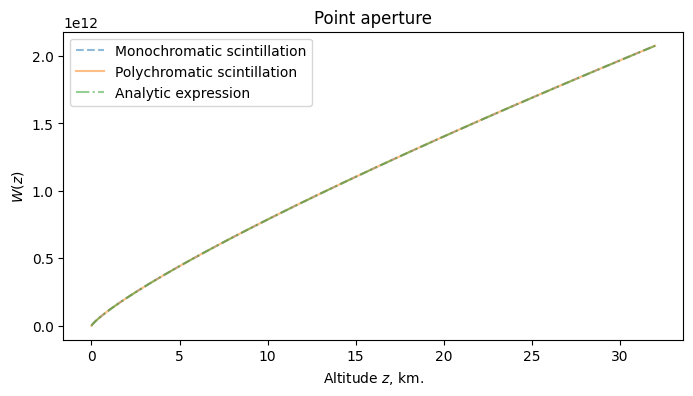

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(Z, wf_point_mono(Z),
         '--', alpha=0.5, label="Monochromatic scintillation")
plt.plot(Z, wf_point_poly(Z),
         alpha=0.5, label="Polychromatic scintillation")
plt.plot(Z, wf_exact_mono,
         '-.',
         alpha=0.5, label="Analytic expression")
plt.title("Point aperture")
plt.xlabel("Altitude $z$, km.")
plt.ylabel("$W(z)$")
plt.legend()

pass

### Compare scintillation with the circular aperture

In [12]:
wf_circular_mono = WeightFunction(sf_mono, equiv_lambda, af_circular, APERTURE_SCALE, 1024)
wf_circular_gauss = WeightFunction(sf_gauss, eff_lambda.to(u.nm).value, af_circular, APERTURE_SCALE, 1024)
wf_circular_poly = WeightFunction(sf_poly, equiv_lambda, af_circular, APERTURE_SCALE, 1024)

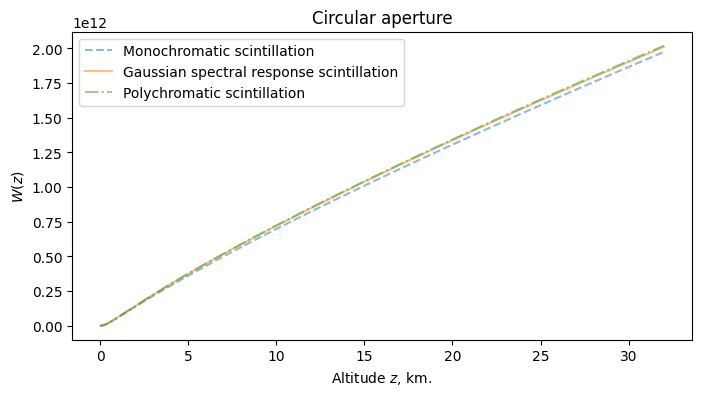

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(Z, wf_circular_mono(Z),
         '--', alpha=0.5, label="Monochromatic scintillation")
plt.plot(Z, wf_circular_gauss(Z),
         alpha=0.5, label="Gaussian spectral response scintillation")
plt.plot(Z, wf_circular_poly(Z),
         '-.',
         alpha=0.5, label="Polychromatic scintillation")
plt.title("Circular aperture")
plt.xlabel("Altitude $z$, km.")
plt.ylabel("$W(z)$")
plt.legend()

pass

### Compare scintillation with the different aperture filters

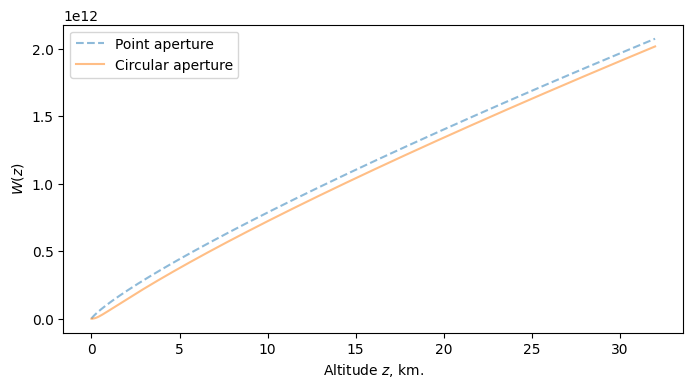

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(Z, wf_point_poly(Z),
         '--', alpha=0.5, label="Point aperture")
plt.plot(Z, wf_circular_poly(Z),
         alpha=0.5, label="Circular aperture")
plt.xlabel("Altitude $z$, km.")
plt.ylabel("$W(z)$")
plt.legend()

pass

## Scintillation weight function for square aperture

We compare the square aperture and the circular aperture of the same area. Two-dimensional numerical integration is rather slow in the current implementation.

In [15]:
af_square = af.Square()
wf_square_poly = WeightFunction2d(sf_poly, equiv_lambda, af_square, 0.5 * np.sqrt(np.pi) * APERTURE_SCALE, 1024)

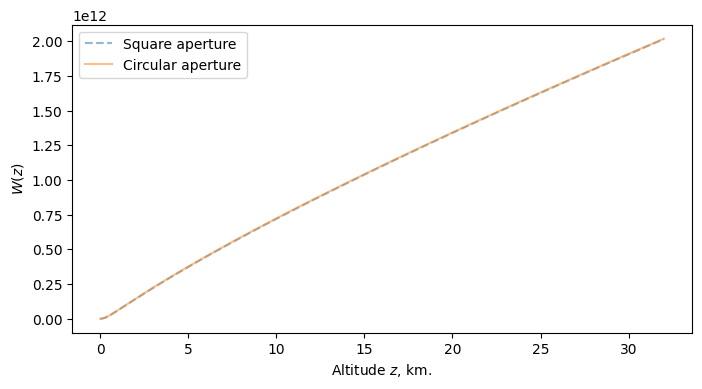

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(Z, wf_square_poly(Z),
         '--', alpha=0.5, label="Square aperture")
plt.plot(Z, wf_circular_poly(Z),
         alpha=0.5, label="Circular aperture")
plt.xlabel("Altitude $z$, km.")
plt.ylabel("$W(z)$")
plt.legend()

pass